# 01 - Data pipeline

Four markets price one US Gulf cargo: JKM or TTF where it lands, BLNG3 or BLNG2 for the ship,
EURUSD to bring TTF into dollars. They close in Singapore, Amsterdam, London and New York, so
the panel has to say when each price was knowable before it says anything about economics.

CSVs in `data/<source>/`, tables in `data/lng.duckdb`, SQL in `sql/`. Rebuild with
`python -m src.data`.

In [1]:
import sys
sys.path.insert(0, "..")

import duckdb
import matplotlib.pyplot as plt

from src import config as c, data

con = duckdb.connect("../data/lng.duckdb", read_only=True)
con.execute("SET TimeZone='UTC'")  # show instants in UTC, not in the laptop's zone


def sql(query):
    return con.execute(query).df()

## 1. Data

Three price tables and the panel built from them. Each futures line is one contract's settle
history, about 40 bars around its expiry; the panel picks a contract per trade date and never
chains them, so no roll adjustment is needed and no price is invented.

In [2]:
sql("SELECT table_name, estimated_size AS rows FROM duckdb_tables() ORDER BY table_name")

,table_name,rows
0,freight_futures_daily,1120
1,fx_daily,268
2,lng_futures_daily,1040
3,netback_panel,516


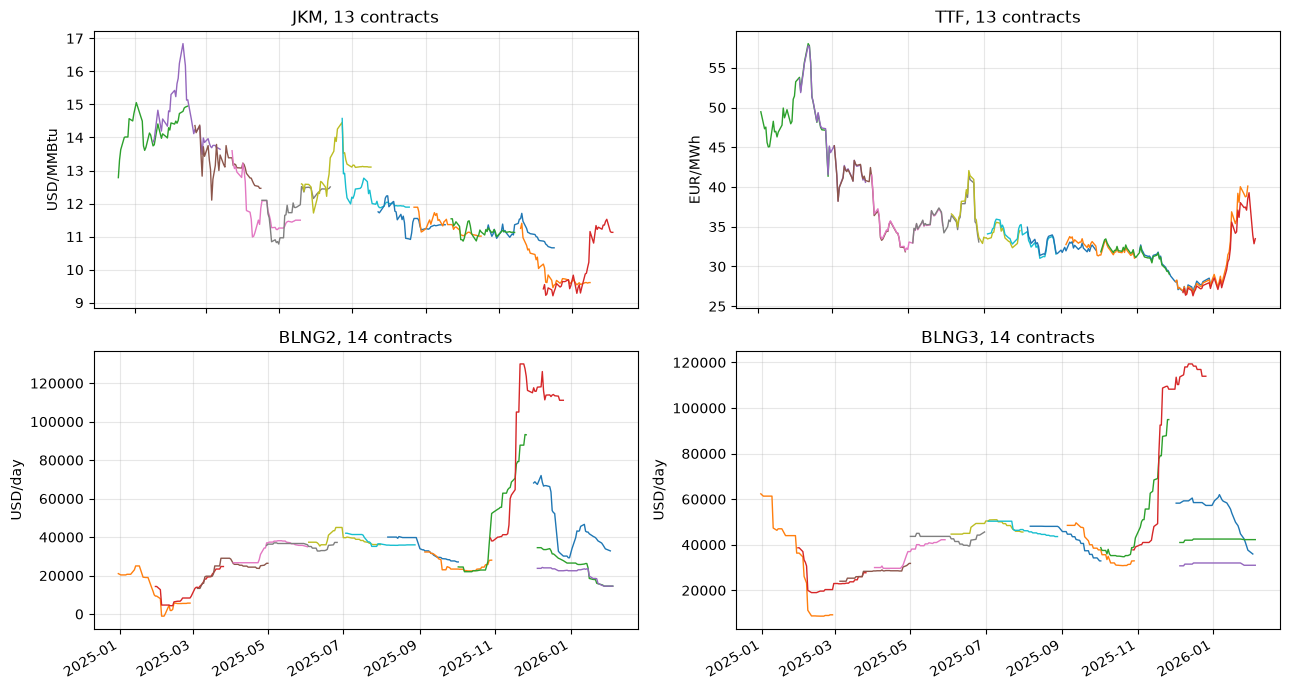

In [3]:
futures = sql("SELECT * FROM lng_futures_daily UNION ALL SELECT * FROM freight_futures_daily")
units = {"JKM": "USD/MMBtu", "TTF": "EUR/MWh", "BLNG2": "USD/day", "BLNG3": "USD/day"}

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, (product, unit) in zip(axes.flat, units.items()):
    strips = futures[futures["product"] == product]
    for _, strip in strips.groupby("contract"):
        ax.plot(strip["trade_date"], strip["settle"], lw=1)
    ax.set_title(f"{product}, {strips['contract'].nunique()} contracts")
    ax.set_ylabel(unit)
    ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()

## 2. Data quality

Rows, nulls, duplicate keys and span, one line per table.

In [4]:
for table, key in [("lng_futures_daily", ["contract", "trade_date"]),
                   ("freight_futures_daily", ["contract", "trade_date"]),
                   ("fx_daily", ["trade_date"]),
                   ("netback_panel", ["route", "trade_date"])]:
    df = sql(f"SELECT * FROM {table}")
    print(f"{table:22} {len(df):5} rows   nulls {df.isna().sum().sum():4}   "
          f"dup keys {df.duplicated(key).sum()}   "
          f"{df['trade_date'].min():%Y-%m-%d} to {df['trade_date'].max():%Y-%m-%d}")

lng_futures_daily       1040 rows   nulls    0   dup keys 0   2024-12-18 to 2026-02-04
freight_futures_daily   1120 rows   nulls    0   dup keys 0   2024-12-31 to 2026-02-04
fx_daily                 268 rows   nulls    0   dup keys 0   2025-02-02 to 2026-02-10
netback_panel            516 rows   nulls  268   dup keys 0   2025-01-02 to 2026-02-04


Keys are unique and the price files are complete. The 268 nulls are `eurusd` on the Tokyo
route, which is quoted in USD and never converted. FX starts six weeks after the futures,
which is why the Rotterdam route only begins in February 2025.

## 3. Point-in-time

Every settle carries the UTC instant it printed, from the local close it is published at. The
check is one date in June against one in January: Singapore has no DST, Amsterdam and London
do.

In [5]:
sql("""
    SELECT DISTINCT product AS source, trade_date, settle_timestamp_utc AS knowable_at
    FROM lng_futures_daily
    WHERE trade_date IN (DATE '2025-06-10', DATE '2026-01-15')
    UNION ALL
    SELECT DISTINCT product, trade_date, settle_timestamp_utc
    FROM freight_futures_daily
    WHERE product = 'BLNG2' AND trade_date IN (DATE '2025-06-10', DATE '2026-01-15')
    UNION ALL
    SELECT 'EURUSD', trade_date, available_timestamp_utc
    FROM fx_daily
    WHERE trade_date IN (DATE '2025-06-10', DATE '2026-01-15')
    ORDER BY source, trade_date
""")

,source,trade_date,knowable_at
0,BLNG2,2025-06-10,2025-06-10 15:00:00+00:00
1,BLNG2,2026-01-15,2026-01-15 16:00:00+00:00
2,EURUSD,2025-06-10,2025-06-11 21:00:00+00:00
3,EURUSD,2026-01-15,2026-01-16 22:00:00+00:00
4,JKM,2025-06-10,2025-06-10 08:30:00+00:00
5,JKM,2026-01-15,2026-01-15 08:30:00+00:00
6,TTF,2025-06-10,2025-06-10 15:00:00+00:00
7,TTF,2026-01-15,2026-01-15 16:00:00+00:00


JKM holds at 08:30 UTC in both seasons, TTF and BLNG2 move an hour. EURUSD is not a print time
but an availability rule: the vendor does not say whether a bar is stamped at the open or the
close, so a bar labelled D counts as usable only at D+1 17:00 New York.

## 4. Panel construction

A row is one trade date on one route, anchored at 17:00 New York, the last of the four closes.
The cargo clock fixes the contracts: loading on next month's program, sailing from the 15th,
landing after 10 days in Rotterdam or 20 in Tokyo, so the destination leg is the delivery
month's contract and the freight leg the loading month's. Prices join with
`merge_asof(direction="backward")`, never forward, tolerance 5 days; FX adds
`allow_exact_matches=False`, which leaves only bars labelled D-1 or earlier.

In [6]:
lng, freight, fx = data.load_lng(), data.load_freight(), data.load_fx()
aligned = data.align(c.ROUTES["us_gulf_to_rotterdam"], data.trade_dates(lng), lng, freight, fx)

stamps = ["asof_timestamp_utc", "dest_contract", "dest_price_date", "dest_settle_utc",
          "freight_contract", "freight_price_date", "freight_settle_utc",
          "fx_price_date", "available_timestamp_utc", "max_staleness_days"]
aligned.set_index("trade_date")[stamps].tail(3).T

trade_date,2026-02-02,2026-02-03,2026-02-04
asof_timestamp_utc,2026-02-02 22:00:00+00:00,2026-02-03 22:00:00+00:00,2026-02-04 22:00:00+00:00
dest_contract,TTFH2026,TTFH2026,TTFH2026
dest_price_date,2026-02-02 00:00:00,2026-02-03 00:00:00,2026-02-04 00:00:00
dest_settle_utc,2026-02-02 16:00:00+00:00,2026-02-03 16:00:00+00:00,2026-02-04 16:00:00+00:00
freight_contract,BLNG2H2026,BLNG2H2026,BLNG2H2026
freight_price_date,2026-02-02 00:00:00,2026-02-03 00:00:00,2026-02-04 00:00:00
freight_settle_utc,2026-02-02 16:00:00+00:00,2026-02-03 16:00:00+00:00,2026-02-04 16:00:00+00:00
fx_price_date,2026-02-01 00:00:00,2026-02-02 00:00:00,2026-02-03 00:00:00
available_timestamp_utc,2026-02-02 22:00:00+00:00,2026-02-03 22:00:00+00:00,2026-02-04 22:00:00+00:00
max_staleness_days,1,1,1


On 2026-02-04 the March TTF and BLNG2 settles printed at 16:00 UTC and the FX bar is the
previous day's, usable at 22:00 UTC - the anchor itself. That is why Rotterdam floors at one
day of staleness rather than zero.

## 5. Controls

Nothing on the row may post-date the anchor, and the oldest input on it has to be recent.

In [7]:
for column in ["dest_settle_utc", "freight_settle_utc", "available_timestamp_utc"]:
    print(f"{column:24} after the anchor: {(aligned[column] > aligned['asof_timestamp_utc']).sum()}")

dest_settle_utc          after the anchor: 0
freight_settle_utc       after the anchor: 0
available_timestamp_utc  after the anchor: 0


In [8]:
sql("""
    SELECT route, max_staleness_days, COUNT(*) AS rows
    FROM netback_panel
    GROUP BY route, max_staleness_days
    ORDER BY route, max_staleness_days
""").pivot(index="route", columns="max_staleness_days", values="rows").fillna(0).astype(int)

max_staleness_days,0,1,2,3,4
route,,,,,
us_gulf_to_rotterdam,0,216,2,28,2
us_gulf_to_tokyo,256,11,0,1,0


No look-ahead. No row carries a price older than 4 days and Tokyo prices off the same day on
256 of its 268 dates, so the 5-day tolerance is a guard rather than a crutch. Rotterdam's tail
is the FX leg again: across a weekend the newest usable bar is Sunday's or Friday's depending
on which the file stamps.

---

`netback_panel`: one row per route and trade date, every price on it knowable at that date's
close. Notebook 02 turns it into a netback and an arb.